In [1]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

In [12]:
num_samples = 10000
input_text_list = []
target_text_list = []

input_characters = []
target_characters = []

#load the data
with open('/content/deu-eng.txt', 'r', encoding='utf-8') as f:
  lines = f.read().split('\n')
for line in lines[: min(num_samples, len(lines)-1)]:
  input_text, target_text, att = line.split('\t')
  target_text = '\t' + target_text + '\n'
  input_text_list.append(input_text)
  target_text_list.append(target_text)
  for char in input_text:
    if char not in input_characters:
      input_characters.append(char)
  for char in target_text:
    if char not in target_characters:
      target_characters.append(char)

input_characters = sorted(list(input_characters))
target_characters = sorted(list(target_characters))
num_encoder = len(input_characters)
num_decoder = len(target_characters)
max_encoder_seq_length = max([len(txt) for txt in input_text_list])
max_decoder_seq_length = max([len(txt) for txt in target_text_list])
print(f'Number of samples:= {len(input_text_list)}')
print(f"Number of unique input tokens: = {num_encoder}")
print(f"Number of unique output tokens: = {num_decoder}")
print(f"Max sequence length for inputs: = {max_encoder_seq_length}")
print(f"Max sequence length for outputs: = {max_decoder_seq_length}")
input_token_index = dict([(char, i) for i, char in enumerate(input_characters)])
target_token_index = dict([(char, i) for i, char in enumerate(target_characters)])

Number of samples:= 10000
Number of unique input tokens: = 71
Number of unique output tokens: = 85
Max sequence length for inputs: = 15
Max sequence length for outputs: = 45


In [15]:
#Convert labels and features into numerical values
input_data_encoder = np.zeros((len(input_text_list), max_encoder_seq_length, num_encoder), dtype='float32')
input_data_decoder = np.zeros((len(target_text_list), max_decoder_seq_length, num_decoder), dtype='float32')
target_data_decoder = np.zeros((len(target_text_list), max_decoder_seq_length, num_decoder), dtype='float32')
for i, (input_text, target_text) in enumerate(zip(input_text_list, target_text_list)):
  for t, char in enumerate(input_text):
    input_data_encoder[i, t, input_token_index[char]] = 1.0
  input_data_encoder[i, t + 1 :, input_token_index[" "]] = 1.0
  for t, char in enumerate(target_text):
    target_data_decoder[i, t, target_token_index[char]] = 1.0
    if t > 0:
      target_data_decoder[i, t - 1, target_token_index[char]] = 1.0
    input_data_decoder[i,t + 1 :, target_token_index[" "]] = 1.0
    target_data_decoder[i, t :, target_token_index[" "]] = 1.0

In [16]:
#Build the model
#encoder
encoder_inputs = tf.keras.Input(shape=(None, num_encoder))
encoder = tf.keras.layers.LSTM(256, return_state=True)
encoder_outputs, state_h, state_c = encoder(encoder_inputs)
encoder_states = [state_h, state_c]
#decoder
decoder_inputs = tf.keras.Input(shape=(None, num_decoder))
decoder_lstm = tf.keras.layers.LSTM(256, return_sequences=True, return_state=True)
decoder_outputs, state_h, state_c = decoder_lstm(decoder_inputs, initial_state=encoder_states)
decoder_dense = tf.keras.layers.Dense(num_decoder, activation='softmax')
decoder_outputs = decoder_dense(decoder_outputs)
model = tf.keras.Model([encoder_inputs, decoder_inputs], decoder_outputs)
model.compile(optimizer='rmsprop', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, None, 71)]           0         []                            
                                                                                                  
 input_2 (InputLayer)        [(None, None, 85)]           0         []                            
                                                                                                  
 lstm (LSTM)                 [(None, 256),                335872    ['input_1[0][0]']             
                              (None, 256),                                                        
                              (None, 256)]                                                        
                                                                                              

In [17]:
#Train model with early stopping condition
history = model.fit(
    [input_data_encoder, input_data_decoder],
    target_data_decoder,
    batch_size=64,
    epochs=50,
    validation_split=0.2,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, min_delta=.001, mode='max')]
)
#save model
model.save('rss_model')

Epoch 1/50
125/125 [==============================] - 20s 141ms/step - loss: 5.7086 - accuracy: 0.9260 - val_loss: 6.7330 - val_accuracy: 0.9333
Epoch 2/50
125/125 [==============================] - 17s 134ms/step - loss: 6.2060 - accuracy: 0.9395 - val_loss: 7.2866 - val_accuracy: 0.9556
Epoch 3/50
125/125 [==============================] - 17s 135ms/step - loss: 6.6840 - accuracy: 0.9452 - val_loss: 7.7802 - val_accuracy: 0.9556
Epoch 4/50
125/125 [==============================] - 17s 134ms/step - loss: 7.1062 - accuracy: 0.9413 - val_loss: 8.2286 - val_accuracy: 0.9333
Epoch 5/50
125/125 [==============================] - 17s 136ms/step - loss: 7.5347 - accuracy: 0.9394 - val_loss: 8.7064 - val_accuracy: 0.9434
Epoch 6/50
125/125 [==============================] - 17s 137ms/step - loss: 7.9867 - accuracy: 0.9443 - val_loss: 9.1978 - val_accuracy: 0.9434
Epoch 7/50
125/125 [==============================] - 17s 135ms/step - loss: 8.4059 - accuracy: 0.9431 - val_loss: 9.6459 - val_ac

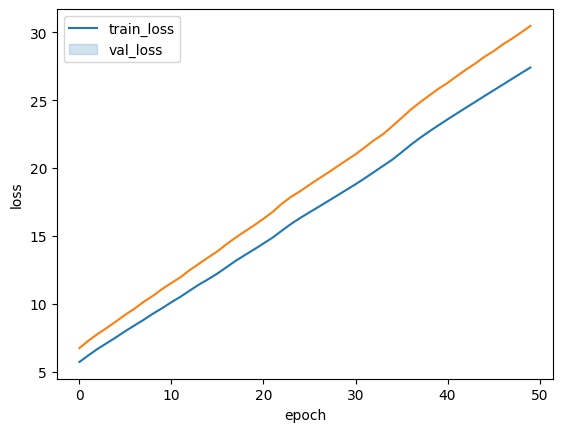

In [18]:
train_history = pd.DataFrame(history.history)
train_history['epoch'] = history.epoch
# Plot train loss
sns.lineplot(x='epoch', y ='loss', data =train_history)
# Plot validation loss
sns.lineplot(x='epoch', y ='val_loss', data =train_history)
# Add legends
plt.legend(labels=['train_loss', 'val_loss'])

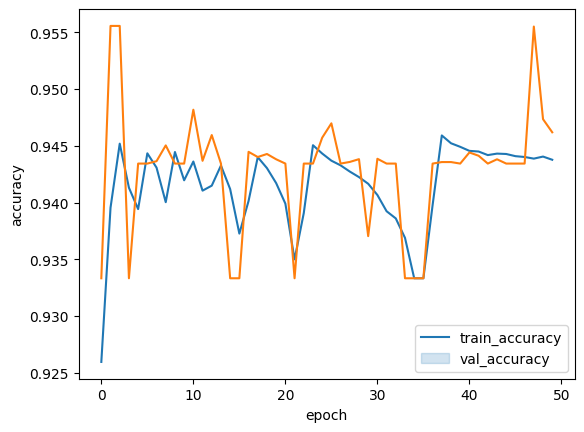

In [19]:
sns.lineplot(x='epoch', y ='accuracy', data =train_history)
# Plot validation loss
sns.lineplot(x='epoch', y ='val_accuracy', data =train_history)
# Add legends
plt.legend(labels=['train_accuracy', 'val_accuracy'])

# Results

Based on the graphs above, I believe that the models are overfitting the data. I do not think I will have much accuracy when I forcast and predict on unseen data

In [26]:
#Create inference model
model = tf.keras.models.load_model('rss_model')
#encoder
encoder_inputs = model.input[0]
encoder_outputs, state_h, state_c = model.layers[2].output
encoder_states = [state_h, state_c]
encoder_model = tf.keras.Model(encoder_inputs, encoder_states)
#decoder
decoder_inputs = model.input[1]
decoder_state_h = tf.keras.Input(shape=(256,), name='state_h')
decoder_state_c = tf.keras.Input(shape=(256,), name='state_c')
decoder_states_inputs = [decoder_state_h, decoder_state_c]
decoder_lstm = model.layers[3]
decoder_outputs, state_h_desc, state_c_desc = decoder_lstm(decoder_inputs, initial_state=decoder_states_inputs)
decoder_states = [state_h_desc, state_c_desc]
decoder_dense = model.layers[4]
decoder_outputs = model.layers[4](decoder_outputs)
decoder_model = tf.keras.Model([decoder_inputs] + decoder_states_inputs, [decoder_outputs] + decoder_states)

In [27]:
#Forcast target texts
reverse_input_char_index = dict((i, char) for char, i in input_token_index.items())
reverse_target_char_index = dict((i, char) for char, i in target_token_index.items())

#define decoder function like the one in the module
def decode_sequence(input_seq):
  states_value = encoder_model.predict(input_seq)
  target_seq = np.zeros((1, 1, num_decoder))
  target_seq[0, 0, target_token_index['\t']] = 1.0
  stop_condition = False
  decoded_sentence = ''
  while not stop_condition:
    output_tokens, h, c = decoder_model.predict([target_seq] + states_value)
    forcasted_index = np.argmax(output_tokens[0, -1, :])
    forcasted_char = reverse_target_char_index[forcasted_index]
    decoded_sentence += forcasted_char
    if forcasted_char == '\n' or len(decoded_sentence) > max_decoder_seq_length:
      stop_condition = True
    target_seq = np.zeros((1, 1, num_decoder))
    target_seq[0, 0, forcasted_index] = 1.0
    states_value = [h, c]
  return decoded_sentence

In [29]:
#Test function on new data
test_input = "awesome"
input_encoder = np.zeros((1, max_encoder_seq_length, num_encoder), dtype='float32')
for t, char in enumerate(test_input):
  input_encoder[0, t, input_token_index[char]] = 1.0
  input_encoder[0, t + 1 :, input_token_index[" "]] = 1.0

test_sentance = decode_sequence(input_encoder)
print(f'Input: {test_input}')
print(f'Output: {test_sentance}')

1/1 [==============================] - 0s 26ms/step
Input: awesome
Output: 	                                             
